# Embryo Presence Classifier

In [36]:
NO_EMBRYO_RANGES = {
    "AAL839-6"  : [(475, 558)],
    "AB91-1"    : [(376, 558)],
    "AC264-1"   : [(209, 343)],
    "ADM715-1-2": [(358, 446)],
    "AG782-8"   : [(375, 565)],
    "AH988-4"   : [(471, 551)],
    "AHS115-5"  : [(272, 293), (474, 557)],
    "AHS599-4"  : [(459, 464)],
    #"ALR493-6"  : [(470, 566)], Truncated images
    "AM33-2"    : [(287, 562)],
    "AM365-7"   : [(178, 265)], # Blurred embryo
    "AM716-1"   : [(476, 572)],
    "AM716-7"   : [(476, 572)],
    "AMT360-1-9": [(390, 394)],
    "AS556-3"   : [(473, 560)],
    "AS662-2"   : [(275, 466)],
    "AS1015-2"  : [(297, 371)],
    "BA518-7"   : [(464, 553)],
    "BA560-1"   : [(351, 380)], # Darkens in this range
    "BA560-2"   : [(476, 574)],
    "BA782-2"   : [(1, 1), (373, 376)],
    "BA1195-9"  : [(1, 8), (253, 276), (377, 663)],
    "BC254-5"   : [(381, 561)],
    "BC277-9"   : [(366, 458)],
    "BC277-10"  : [(179, 264)], # Darkens in this range
    "BC518-6"   : [(419, 551)],
    "BC750-7"   : [(465, 555)],
    "BC973-4"   : [(473, 555)],
    "BE327-2"   : [(168, 283), (473, 574)],
    "BE413-3"   : [(353, 418)],
    "BE645-7"   : [(375, 559)],
    "BF924-3"   : [(471, 557)],
    "BG201-1"   : [(191, 274)],
    "BG723-5"   : [(377, 555)],
    "BH034-4"   : [(374, 564)],
    "BI224-2"   : [(357, 423)],
    #"BJ492-8"   : [(145, 147)], Truncated Images
    "BJ497-7"   : [(190, 460)],
    "BJ3371-9"  : [(275, 413)],
    "BL042-8"   : [(478, 564)],
    "BL285-1-3"   : [(473, 567)],
    "BL366-6"   : [(470, 559)],
    "BL526-1"   : [(372, 656)],
    "BL526-5"   : [(1, 13), (468, 656)],
    "BM007-9"   : [(375, 560)],
    "BM076-4"   : [(466, 554)],
    "BM201-1"   : [(374, 569)],
    #"BM256-1"   : [(460, 555)], Truncated images
    "BM352-6"   : [(377, 567)],
    "BM414-3"   : [(350, 413)],
    "BM968-3"   : [(295, 362)],
    "BMH857-2"  : [(367, 456)],
    "BMS819-7"  : [(484, 569)],
    "BN356-3"   : [(356, 423)],
    "BN356-6"   : [(356, 363)],
    #"BN1010-5"  : [(1, 1)], Truncated images
    "BO613-7"   : [(462, 564)],
    "BR953-7"   : [(468, 563)],
    "BS495-9"   : [(472, 560)],
}

EXCLUDE_FROM_TRAIN = {"AM365-7"}  # blurred embryo – keep for later tests
TRAIN_EMBRYOS = sorted(NO_EMBRYO_RANGES.keys())

## 1. Imports, and Dataset

### Imports

In [37]:
# Standard libs
import os, math, random, warnings
from pathlib import Path
from collections import Counter

# Numerics / data
import numpy as np
import pandas as pd

# Imaging & plots
from PIL import Image
import matplotlib.pyplot as plt

# Notebook display
from IPython.display import display

# Matplotlib defaults
plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['axes.grid'] = False
warnings.filterwarnings("ignore")

# Reproducibility
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# RegEx support in python
import re

def extract_index(fp):
    """Extracts RUN##### index from a frame filename."""
    m = re.search(r"RUN(\d+)", fp.name)
    return int(m.group(1)) if m else None

### Paths

In [ ]:
PROJECT_ROOT = Path('..').resolve()
IMG_DIR = PROJECT_ROOT / 'data' / 'embryo_dataset_bronze'
ANN_DIR = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'

assert IMG_DIR.exists(), f"Not found: {IMG_DIR}  <-- check your folder structure"
assert ANN_DIR.exists(), f"Not found: {ANN_DIR}  <-- check your folder structure"

# Each subfolder in IMG_DIR corresponds to one embryo/video
embryo_dirs = TRAIN_EMBRYOS
print(f"Found {len(embryo_dirs)} embryo folders under {IMG_DIR}")

Found 55 embryo folders under /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/data/embryo_dataset


In [39]:
from torch.utils.data import Dataset, DataLoader
import torch, torch.nn as nn

class EmbryoPresenceDataset(Dataset):
    def __init__(self, img_dir, embryo_ids, no_embryo_ranges, transform=None):
        self.samples = []   # list of (path, label)
        self.transform = transform

        for eid in embryo_ids:
            folder = img_dir / eid
            if not folder.is_dir():
                print(f"⚠️ folder {folder} missing – skipped")
                continue

            # collect frame paths with index
            idx2path = {extract_index(fp): fp
                        for fp in folder.glob("*.jp*g")
                        if extract_index(fp) is not None}

            # enumerate frames
            for idx, fp in idx2path.items():
                # decide label
                absent = any(s <= idx <= e for (s, e) in no_embryo_ranges[eid])
                label = 0 if absent else 1
                self.samples.append((fp, label))

        print(f"Dataset built with {len(self.samples):,} frames")

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        try:
            with Image.open(path) as im:
                im = im.convert("L")   # 1‑channel grayscale
                if self.transform: im = self.transform(im)
            return im, torch.tensor(label, dtype=torch.long)
        except OSError as e:
            print(f"⚠️ Skipping truncated image: {path} - {e}")
            dummy_image = torch.zeros(1, self.transform.transforms[0].size[0], self.transform.transforms[0].size[1])
            return dummy_image, torch.tensor(label, dtype=torch.long)

### Transforms & Dataloader

In [40]:
import torchvision.transforms as T
import torchvision.transforms.v2 as v2

IMG_SIZE = 224
tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])

train_aug = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(45),
    v2.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0),
                         ratio=(0.9, 1.1)),
    v2.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
    v2.RandomAdjustSharpness(1.5, p=0.3),
])

# --- embryo-level train / val / test split --------------------
import random

val_frac  = 0.10          # 20 % of embryos
test_frac = 0.10          # 20 % of embryos

all_embryos = TRAIN_EMBRYOS.copy()
random.seed(42)
random.shuffle(all_embryos)

n_val  = int(len(all_embryos) * val_frac)
n_test = int(len(all_embryos) * test_frac)

val_embryos  = all_embryos[:n_val]
test_embryos = all_embryos[n_val:n_val + n_test]
train_embryos = all_embryos[n_val + n_test:]

print(f"Train embryos: {train_embryos}")
print(f"Val   embryos: {val_embryos}")
print(f"Test  embryos: {test_embryos}")

# build three **separate** datasets so no embryo appears in two splits
train_ds = EmbryoPresenceDataset(IMG_DIR, train_embryos, NO_EMBRYO_RANGES, transform=tfm)
val_ds   = EmbryoPresenceDataset(IMG_DIR, val_embryos,   NO_EMBRYO_RANGES, transform=tfm)
test_ds  = EmbryoPresenceDataset(IMG_DIR, test_embryos,  NO_EMBRYO_RANGES, transform=tfm)

BATCH_SIZE = 64
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
# --------------------------------------------------------------

Train embryos: ['AM365-7', 'BH034-4', 'BL526-5', 'BM201-1', 'BE645-7', 'BS495-9', 'ADM715-1-2', 'BC254-5', 'BM414-3', 'AG782-8', 'BE413-3', 'AM716-1', 'BM007-9', 'BC277-10', 'BL285-1-3', 'BC518-6', 'AAL839-6', 'BC750-7', 'BN356-6', 'BA560-1', 'BG201-1', 'BJ497-7', 'BC973-4', 'AMT360-1-9', 'BL366-6', 'BG723-5', 'BMH857-2', 'AS1015-2', 'BM352-6', 'BO613-7', 'AC264-1', 'BE327-2', 'BL042-8', 'AH988-4', 'BI224-2', 'BM076-4', 'AHS115-5', 'AM33-2', 'AS556-3', 'AS662-2', 'BA518-7', 'BM968-3', 'AB91-1', 'AHS599-4', 'BL526-1']
Val   embryos: ['BF924-3', 'BC277-9', 'BMS819-7', 'AM716-7', 'BA1195-9']
Test  embryos: ['BA782-2', 'BN356-3', 'BR953-7', 'BJ3371-9', 'BA560-2']
Dataset built with 23,358 frames
Dataset built with 2,816 frames
Dataset built with 2,349 frames


### Model Definition

In [41]:
import torchvision.models as models

device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)  # adapt for 1‑channel
model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

### Training Loop

In [42]:
import copy
from tqdm.auto import tqdm

EPOCHS = 50
best_val_loss = float("inf")
patience = 10          # epochs without improvement
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(1, EPOCHS+1):
    # ---- train ----
    model.train()
    running_loss, correct = 0., 0
    for x, y in tqdm(train_dl, desc=f"Epoch {epoch}", leave=False):
        x = train_aug(x)
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        y_hat = model(x)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        correct += (y_hat.argmax(1) == y).sum().item()

    train_loss = running_loss / len(train_ds)
    train_acc  = correct / len(train_ds)

    # ---- validate ----
    model.eval()
    running_vloss, val_correct = 0.0, 0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            vloss = criterion(y_hat, y)
            running_vloss += vloss.item() * x.size(0)
            val_correct   += (y_hat.argmax(1) == y).sum().item()

    val_loss = running_vloss / len(val_ds)
    val_acc  = val_correct  / len(val_ds)
    # ----- early-stopping on val_loss -----
    if val_loss < best_val_loss - 1e-6:      # small delta to avoid ties
        best_val_loss      = val_loss
        epochs_no_improve  = 0
        best_model_wts     = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"No val-loss improvement for {patience} epochs → stopping early.")
            break

    print(f"[{epoch}] loss {train_loss:.4f} | train_acc {train_acc:.3f} | val loss {val_loss:.4f} | val acc {val_acc:.3f}")


model.load_state_dict(best_model_wts)

[1] loss 0.0933 | train_acc 0.963 | val loss 0.0094 | val acc 0.998


[2] loss 0.0438 | train_acc 0.983 | val loss 0.0132 | val acc 0.998


[3] loss 0.0362 | train_acc 0.987 | val loss 0.0220 | val acc 0.999


[4] loss 0.0268 | train_acc 0.991 | val loss 0.0138 | val acc 0.998


[5] loss 0.0308 | train_acc 0.989 | val loss 0.0161 | val acc 0.999


...

[8] loss 0.0238 | train_acc 0.991 | val loss 0.0890 | val acc 0.961


[9] loss 0.0198 | train_acc 0.992 | val loss 0.0106 | val acc 0.999


[10] loss 0.0293 | train_acc 0.990 | val loss 0.0143 | val acc 0.998


No val-loss improvement for 10 epochs → stopping early.


<All keys matched successfully>

### Evaluation

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_true = [], []

for x, y in test_dl:
    logits = model(x.to(device))
    preds  = logits.argmax(1).cpu()
    all_preds.extend(preds.numpy())
    all_true.extend(y.numpy())

test_acc = (np.array(all_preds) == np.array(all_true)).mean()
print(f"★ Test accuracy: {test_acc:.3f}")

print("\nClassification report (EMBRYO = 1, NO_EMBRYO = 0):")
print(classification_report(all_true, all_preds, target_names=["NO_EMBRYO", "EMBRYO"], digits=3))

★ Test accuracy: 1.000

Classification report (EMBRYO = 1, NO_EMBRYO = 0):
              precision    recall  f1-score   support

   NO_EMBRYO      1.000     0.998     0.999       407
      EMBRYO      0.999     1.000     1.000      1942

    accuracy                          1.000      2349
   macro avg      1.000     0.999     0.999      2349
weighted avg      1.000     1.000     1.000      2349



### Save Model + quick demo

Model saved to embryo_presence_models/embryo_presence_resnet18.pth


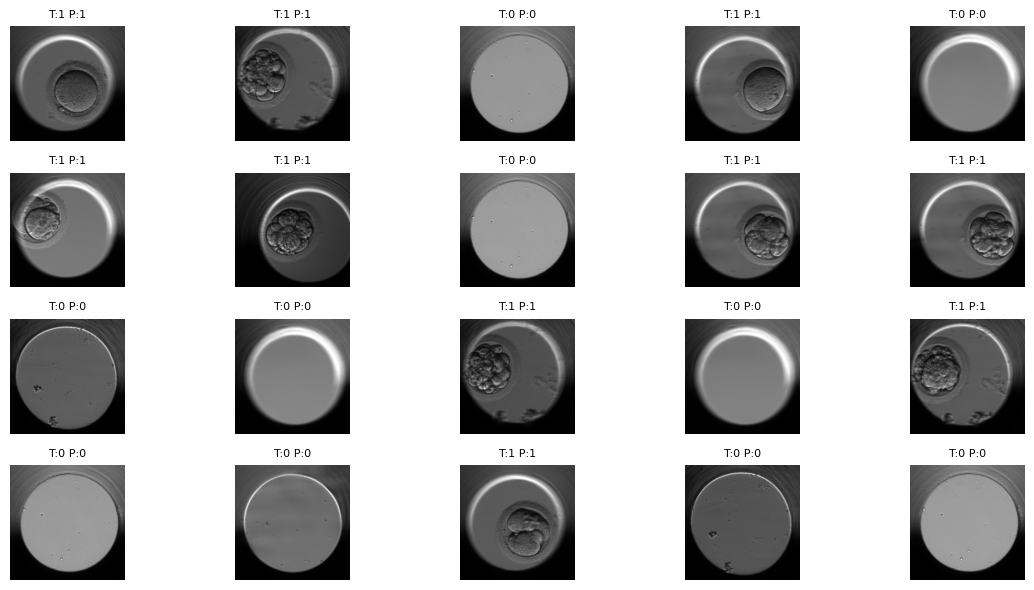

In [44]:
model.eval()
MODEL_PATH = "embryo_presence_models/embryo_presence_resnet18.pth"
torch.save(model, MODEL_PATH)
print("Model saved to", MODEL_PATH)

# Visualise a few predictions
idx_present = [i for i, (_, lbl) in enumerate(test_ds.samples) if lbl == 1]
idx_absent  = [i for i, (_, lbl) in enumerate(test_ds.samples) if lbl == 0]

n_each = 10
sel_inds = random.sample(idx_present, n_each) + random.sample(idx_absent, n_each)
random.shuffle(sel_inds)

images = torch.stack([test_ds[i][0] for i in sel_inds])
labels = torch.tensor([test_ds[i][1] for i in sel_inds])

preds = model(images.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(4, 5, figsize=(12, 6))
for ax, img, lab, pred in zip(axes.flatten(), images, labels, preds):
    ax.imshow(img.squeeze(0).numpy()*0.5 + 0.5, cmap="gray")
    ax.set_title(f"T:{lab.item()} P:{pred.item()}", fontsize=8)
    ax.axis("off")
plt.tight_layout()

### Grad-CAM montage: 50% Embryo, 50% No Embryo (test frames)


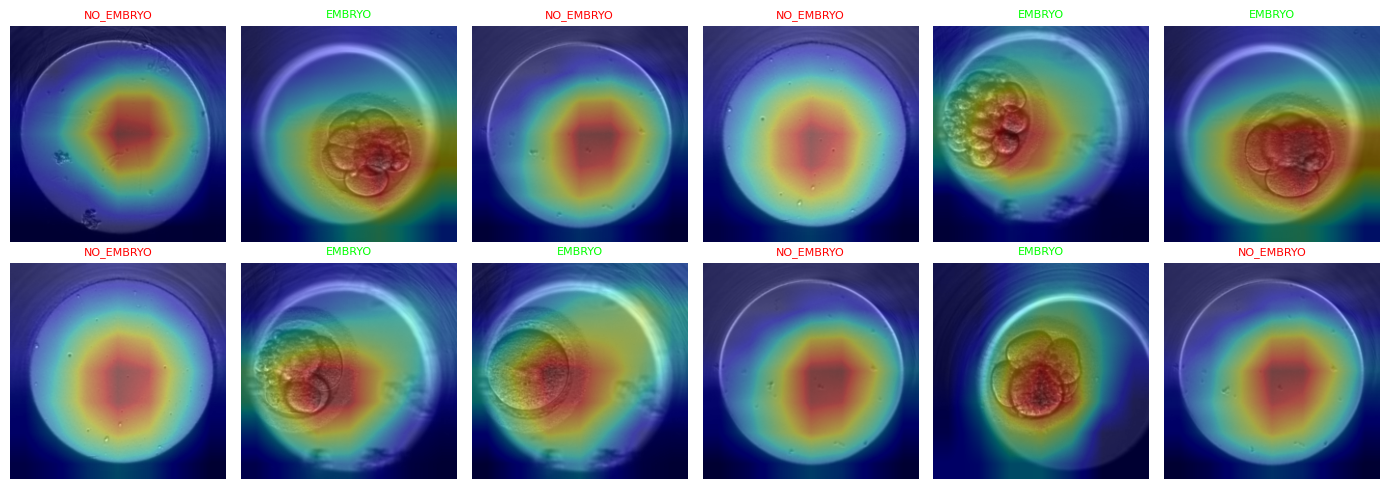

In [48]:
# --------------------------------------------------------------
# Grad-CAM montage: 50 % EMBRYO, 50 % NO_EMBRYO (test frames)
# --------------------------------------------------------------
from torchcam.methods import GradCAM
import torch.nn.functional as F

model.eval()                                  # keep weights frozen
cam_extractor = GradCAM(model, target_layer=model.layer4[-1])

# ----- 1. Balanced sampling -------------------------------------------------
random.seed(0)

idx_embryo = [i for i, (_, lbl) in enumerate(test_ds.samples) if lbl == 1]
idx_empty  = [i for i, (_, lbl) in enumerate(test_ds.samples) if lbl == 0]

n_each = 6
sel_inds = random.sample(idx_embryo, n_each) + random.sample(idx_empty, n_each)
random.shuffle(sel_inds)

# ----- 2. Compute CAMs -------------------------------------------------------
images, labels, cams = [], [], []
for idx in sel_inds:
    x, lbl = test_ds[idx]           # x: [C,H,W] tensor
    x_batch = x.unsqueeze(0).to(device)

    # Forward *with* gradients
    logits = model(x_batch)

    # CAM for the predicted class (or use lbl to see GT class)
    cls_id = logits.argmax(1).item()
    cam_small = cam_extractor(cls_id, scores=logits)[0]
    cam_small = cam_small.squeeze(0)

    # Upsample to input resolution
    cam_up = F.interpolate(cam_small.unsqueeze(0).unsqueeze(0),
                           size=(IMG_SIZE, IMG_SIZE),
                           mode='bilinear',
                           align_corners=False).squeeze()

    cam_up = (cam_up - cam_up.min()) / (cam_up.max() - cam_up.min() + 1e-6)

    images.append(x)
    labels.append(lbl)
    cams.append(cam_up.cpu())

# ----- 3. Plot grid ----------------------------------------------------------
n_cols = 6
n_rows = math.ceil(len(images) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.5*n_rows))

for ax, img, lbl, cam in zip(axes.flatten(), images, labels, cams):
    base = img.squeeze()*0.5 + 0.5      # un-normalise to [0,1]
    ax.imshow(base.numpy(), cmap='gray')
    ax.imshow(cam.numpy(), cmap='jet', alpha=0.4)
    ax.set_title("EMBRYO" if lbl==1 else "NO_EMBRYO", fontsize=8,
                 color='lime' if lbl==1 else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()
# --------------------------------------------------------------